In [1]:
import mlx.core as mx
import mlx.nn as nn
import mlx.utils as utils
import tiktoken

In [2]:
from importlib.metadata import version

print("mlx version:", version("mlx"))
print("tiktoken version:", version("tiktoken"))

mlx version: 0.29.2
tiktoken version: 0.12.0


In [3]:
import os
import requests

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

In [4]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

tokens = tokenizer.encode_ordinary(raw_text[:99])
print(tokens)

strings = tokenizer.decode(tokens)
print(strings)

[40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438, 568, 340, 373, 645, 220]
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [6]:
from mlxgpt.dataloader import create_gpt_dataloader

max_length = 4
dataloader = create_gpt_dataloader(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
for i in range(2):
    inputs, targets = next(data_iter)
    print(f"Inputs:\n {inputs}")
    print(f"Targets:\n {targets}\n")


Inputs:
 array([[40, 367, 2885, 1464],
       [1807, 3619, 402, 271],
       [10899, 2138, 257, 7026],
       ...,
       [568, 340, 373, 645],
       [1049, 5975, 284, 502],
       [284, 3285, 326, 11]], dtype=int32)
Targets:
 array([[367, 2885, 1464, 1807],
       [3619, 402, 271, 10899],
       [2138, 257, 7026, 15632],
       ...,
       [340, 373, 645, 1049],
       [5975, 284, 502, 284],
       [3285, 326, 11, 287]], dtype=int32)

Inputs:
 array([[287, 262, 6001, 286],
       [465, 13476, 11, 339],
       [550, 5710, 465, 12036],
       ...,
       [2241, 287, 257, 4489],
       [64, 319, 262, 34686],
       [41976, 13, 357, 10915]], dtype=int32)
Targets:
 array([[262, 6001, 286, 465],
       [13476, 11, 339, 550],
       [5710, 465, 12036, 11],
       ...,
       [287, 257, 4489, 64],
       [319, 262, 34686, 41976],
       [13, 357, 10915, 314]], dtype=int32)



In [7]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = nn.Embedding(vocab_size, output_dim)

input_ids, _ = next(data_iter)

print("Input IDs shape:", input_ids.shape)
print("Input IDs type:", type(input_ids))

input_embeddings = token_embedding_layer(input_ids)
print("Input embeddings shape:", input_embeddings.shape)

Input IDs shape: (8, 4)
Input IDs type: <class 'mlx.core.array'>
Input embeddings shape: (8, 4, 256)


In [8]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout=0.0, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.mask = mx.tril(mx.ones((context_length, context_length)), k=0) # New

    def __call__(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(0, 2, 1) # Changed transpose
        attn_scores = mx.where(self.mask[:num_tokens, :num_tokens] > 0, attn_scores, -mx.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = mx.softmax(attn_scores / self.d_out ** 0.5, axis=-1)
        attn_weights = self.dropout(attn_weights) # New
 
        context_vec = attn_weights @ values
        return context_vec


In [9]:
inputs = mx.array(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size, d=2

batch = mx.stack([inputs, inputs], axis=0)
print(batch.shape) # 2 inputs with 6 tokens each, and each token has embedding dimension 3

context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

(2, 6, 3)
array([[[-0.0834499, -0.340671],
        [-0.148968, -0.187432],
        [-0.165292, -0.134476],
        [-0.170289, -0.0887263],
        [-0.0981287, -0.0829053],
        [-0.142878, -0.0579409]],
       [[-0.0834499, -0.340671],
        [-0.148968, -0.187432],
        [-0.165292, -0.134476],
        [-0.170289, -0.0887263],
        [-0.0981287, -0.0829053],
        [-0.142878, -0.0579409]]], dtype=float32)
context_vecs.shape: (2, 6, 2)


In [10]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
                      for _ in range(num_heads)]

    def __call__(self, x):
        return mx.concat([head(x) for head in self.heads], axis=-1)

In [11]:
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=3
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

array([[[0.36174, -0.465077, 0.231006, 0.346628, -0.31614, 0.0323243],
        [0.431866, -0.304105, 0.390506, 0.156955, -0.224215, 0.0277117],
        [0.451362, -0.251077, 0.444014, 0.096185, -0.193481, 0.0194538],
        [0.412504, -0.187446, 0.414918, 0.0420186, -0.147936, 0.0316664],
        [0.350903, -0.190851, 0.396118, 0.0798747, -0.150976, -0.0449027],
        [0.363601, -0.151893, 0.396342, 0.020869, -0.124365, 0.00111997]],
       [[0.36174, -0.465077, 0.231006, 0.346628, -0.31614, 0.0323243],
        [0.431866, -0.304105, 0.390506, 0.156955, -0.224215, 0.0277117],
        [0.451362, -0.251077, 0.444014, 0.096185, -0.193481, 0.0194538],
        [0.412504, -0.187446, 0.414918, 0.0420186, -0.147936, 0.0316664],
        [0.350903, -0.190851, 0.396118, 0.0798747, -0.150976, -0.0449027],
        [0.363601, -0.151893, 0.396342, 0.020869, -0.124365, 0.00111997]]], dtype=float32)
context_vecs.shape: (2, 6, 6)


In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self._mask = mx.tril(mx.ones((context_length, context_length)), k=0)

    def __call__(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.reshape(b, num_tokens, self.num_heads, self.head_dim)
        values = values.reshape(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.reshape(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(0, 2, 1, 3)
        queries = queries.transpose(0, 2, 1, 3)
        values = values.transpose(0, 2, 1, 3)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(0, 1, 3, 2)  # Dot product for each head

        # Use the mask to fill attention scores
        attn_scores = mx.where(self._mask[:num_tokens, :num_tokens] > 0, attn_scores, -mx.inf) 

        attn_weights = mx.softmax(attn_scores / keys.shape[-1]**0.5, axis=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(0, 2, 1, 3)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [13]:
mha = MultiHeadAttention(
    d_in, d_out * 3, context_length, 0.0, num_heads=3
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

array([[[0.0926092, 0.335254, 0.448579, -0.15435, 0.362475, 0.00248632],
        [0.114136, 0.283134, 0.423438, -0.177219, 0.419962, 0.0143256],
        [0.117562, 0.262616, 0.411739, -0.186513, 0.439835, 0.0185512],
        [0.069083, 0.252076, 0.36269, -0.206305, 0.434537, 0.00364792],
        [0.0123824, 0.203355, 0.303397, -0.236155, 0.446365, 0.00473573],
        [0.0213863, 0.22611, 0.314017, -0.227937, 0.44017, -0.0031477]],
       [[0.0926092, 0.335254, 0.448579, -0.15435, 0.362475, 0.00248632],
        [0.114136, 0.283134, 0.423438, -0.177219, 0.419962, 0.0143256],
        [0.117562, 0.262616, 0.411739, -0.186513, 0.439835, 0.0185512],
        [0.069083, 0.252076, 0.36269, -0.206305, 0.434537, 0.00364792],
        [0.0123824, 0.203355, 0.303397, -0.236155, 0.446365, 0.00473573],
        [0.0213863, 0.22611, 0.314017, -0.227937, 0.44017, -0.0031477]]], dtype=float32)
context_vecs.shape: (2, 6, 6)


In [14]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [15]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def __call__(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(mx.arange(seq_len))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def __call__(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def __call__(self, x):
        # This layer does nothing and just returns its input.
        return x

In [16]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(mx.array(tokenizer.encode(txt1)))
batch.append(mx.array(tokenizer.encode(txt2)))
batch = mx.stack(batch, axis=0)
print(batch)

array([[6109, 3626, 6100, 345],
       [6109, 1110, 6622, 257]], dtype=int32)


In [17]:
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: (2, 4, 50257)
array([[[-0.0498985, 0.0077471, -0.024586, ..., 0.020632, -0.00596586, -0.0768519],
        [0.00854576, 0.0120639, -0.025462, ..., 0.0414183, 0.0404478, -0.0579112],
        [-0.00571773, 0.0230586, -0.00452047, ..., 0.0532734, -0.0225479, -0.0281526],
        [-0.0327937, 0.0379393, 0.0138844, ..., -0.0250107, 0.0232687, -0.0236585]],
       [[-0.0495594, 0.00517148, -0.0108257, ..., 0.0135754, -0.00771232, -0.0617381],
        [0.0221426, 0.0454285, 0.00149214, ..., 0.0151566, 0.0158764, -0.013002],
        [0.0374747, 0.0577167, 0.0379667, ..., 0.0372515, -0.0311712, -0.00364508],
        [0.039067, -0.00767198, -0.0033412, ..., -0.0186934, 0.0290241, 0.0444612]]], dtype=float32)


In [18]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = mx.ones(emb_dim)
        self.shift = mx.zeros(emb_dim)

    def __call__(self, x):
        mean = mx.mean(x, axis=-1, keepdims=True)
        var = mx.var(x, axis=-1, keepdims=True, ddof=0)
        norm_x = (x - mean) / mx.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [19]:
batch_example = mx.random.uniform(shape=(2, 5)) 
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

mean = mx.mean(out_ln, axis=-1, keepdims=True)
var = mx.var(out_ln, axis=-1, ddof=0, keepdims=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 array([[-1.19209e-07],
       [1.03563e-07]], dtype=float32)
Variance:
 array([[0.999876],
       [0.999802]], dtype=float32)


In [20]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def __call__(self, x):
        return 0.5 * x * (1 + mx.tanh(
            mx.sqrt(mx.array(2.0 / mx.pi)) * 
            (x + 0.044715 * mx.power(x, 3))
        ))

Matplotlib is building the font cache; this may take a moment.


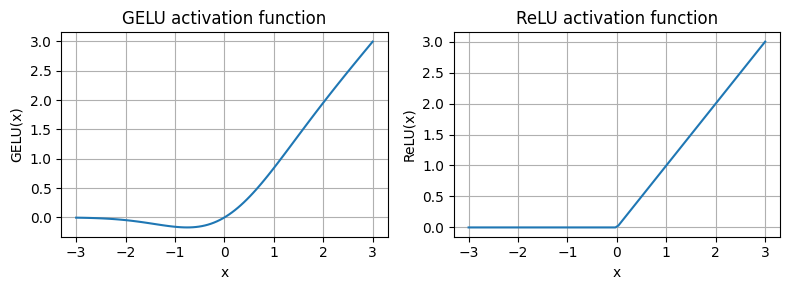

In [21]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = mx.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def __call__(self, x):
        return self.layers(x)

In [23]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = mx.random.uniform(shape=(2, 3, 768))
out = ffn(x)
print(out.shape)

(2, 3, 768)


In [24]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def __call__(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [25]:
x = mx.random.uniform(shape=(2, 4, 768))  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: (2, 4, 768)
Output shape: (2, 4, 768)


In [26]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def __call__(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(mx.arange(seq_len))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [27]:
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 array([[6109, 3626, 6100, 345],
       [6109, 1110, 6622, 257]], dtype=int32)

Output shape: (2, 4, 50257)
array([[[-0.51297, 0.021048, 0.612599, ..., 1.31028, 0.2087, 1.52389],
        [-0.172034, -0.0998489, 0.0514427, ..., 0.489528, 0.211795, 0.829924],
        [0.0633627, 0.033175, 0.394188, ..., 0.795542, -0.276472, 0.0725563],
        [-0.0362582, -0.295071, -0.143813, ..., 0.751198, -0.175186, -0.348247]],
       [[-0.165765, 0.096133, 0.297165, ..., 0.999785, 0.194947, -0.513802],
        [-0.309231, 0.551359, 0.00195271, ..., 1.12705, 0.0611583, 0.0248914],
        [-0.36569, -0.0778954, 1.23319, ..., 0.619446, 0.460326, 0.321878],
        [-0.0541013, 0.486266, 0.493416, ..., 0.461213, 0.410253, 0.129736]]], dtype=float32)


In [28]:
params = model.parameters()

total_params = utils.tree_reduce(lambda acc, p: acc + p.size, model.parameters(), 0)

print(f"Total number of parameters: {total_params:,}")

print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

total_params_gpt2 =  total_params - utils.tree_reduce(lambda acc, p: acc + p.size, model.out_head.parameters(), 0)
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")


Total number of parameters: 163,009,536
Token embedding layer shape: (50257, 768)
Output layer shape: (50257, 768)
Number of trainable parameters considering weight tying: 124,412,160


In [29]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = mx.softmax(logits, axis=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = mx.argmax(probas, axis=-1, keepdims=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = mx.concatenate([idx, idx_next], axis=1)  # (batch, n_tokens+1)

    return idx


In [30]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = mx.expand_dims(mx.array(encoded), axis=0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: (1, 4)


In [31]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: array([[15496, 11, 314, ..., 8002, 21772, 25369]], dtype=int64)
Output length: 10


In [32]:
decoded_text = tokenizer.decode(mx.squeeze(out, axis=0).tolist())
print(decoded_text)

Hello, I am Horowitzpackpackpack virgin strat


In [33]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

In [34]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = mx.expand_dims(mx.array(encoded), axis=0)  # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you guess upgr Cutrequire upgr client rugby client client client


In [35]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [36]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [37]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [38]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [39]:
from mlxgpt.dataloader import create_gpt_dataloader

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

train_loader = create_gpt_dataloader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
)

val_loader = create_gpt_dataloader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
)

In [40]:
print("Train loader:")
for x, y in iter(train_loader):
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in iter(val_loader):
    print(x.shape, y.shape)

Train loader:
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)
(2, 256) (2, 256)

Validation loader:
(2, 256) (2, 256)


In [41]:
print("Train loader:")
for x, y in iter(train_loader):
    print(x)
    print(y)

print("\nValidation loader:")
for x, y in iter(val_loader):
    print(x)
    print(y)


Train loader:
array([[198, 1544, 13818, ..., 13476, 286, 616],
       [673, 1908, 329, ..., 514, 2474, 198]], dtype=int32)
array([[1544, 13818, 4622, ..., 286, 616, 12036],
       [1908, 329, 345, ..., 2474, 198, 198]], dtype=int32)
array([[1459, 714, 1239, ..., 1517, 484, 1444],
       [11, 17728, 257, ..., 422, 465, 2330]], dtype=int32)
array([[714, 1239, 423, ..., 484, 1444, 616],
       [17728, 257, 8500, ..., 465, 2330, 22645]], dtype=int32)
array([[503, 4291, 262, ..., 19217, 24887, 13431],
       [12036, 683, 0, ..., 284, 616, 835]], dtype=int32)
array([[4291, 262, 4252, ..., 24887, 13431, 13],
       [683, 0, 3226, ..., 616, 835, 286]], dtype=int32)
array([[271, 10899, 550, ..., 29543, 2745, 11],
       [438, 292, 339, ..., 13674, 5891, 438]], dtype=int32)
array([[10899, 550, 366, ..., 2745, 11, 314],
       [292, 339, 550, ..., 5891, 438, 1092]], dtype=int32)
array([[10197, 832, 262, ..., 9074, 13, 402],
       [314, 4752, 340, ..., 691, 12226, 318]], dtype=int32)
array([[832,

In [42]:
def calc_loss_batch(model: nn.Module, input_batch: mx.array, target_batch: mx.array) -> mx.array:
    logits = model(input_batch)
    loss = nn.losses.cross_entropy(logits.flatten(0, 1), target_batch.flatten(), reduction="mean")
    return loss


def calc_loss_loader(model, data_loader, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(model, input_batch, target_batch)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [43]:
input_ids, target_ids = next(iter(train_loader))
print("Input IDs shape:", input_ids.shape)
print("Target IDs shape:", target_ids.shape)
print(input_ids)

Input IDs shape: (2, 256)
Target IDs shape: (2, 256)
array([[198, 1544, 13818, ..., 13476, 286, 616],
       [673, 1908, 329, ..., 514, 2474, 198]], dtype=int32)


In [44]:
loss = calc_loss_batch(model, input_ids, target_ids)
print("Loss:", loss)

Loss: array(11.0146, dtype=float32)


In [45]:
train_loss = calc_loss_loader(model, train_loader)
val_loss = calc_loss_loader(model, val_loader)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.957370440165201
Validation loss: 10.909260749816895


In [46]:
# perplexity
train_perplexity = mx.exp(train_loss)
val_perplexity = mx.exp(val_loss)

print("Training perplexity", train_perplexity)
print("Valication perplexity", val_perplexity)

Training perplexity array(57375.4, dtype=float32)
Valication perplexity array(54680.4, dtype=float32)


In [47]:
def train_model_simple(model, train_loader, val_loader, optimizer, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Create a function that computes the loss and gradients
    loss_and_grad_fn = nn.value_and_grad(model, calc_loss_batch)

    # @mx.compile
    def train_step(x, y):
        # value_and_grad returns a tuple of (loss, gradients)
        loss, grads = loss_and_grad_fn(model, x, y)
        optimizer.update(model, grads)
        return loss

    # Main training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            loss = train_step(input_batch, target_batch)
            tokens_seen += input_batch.size
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, eval_iter):
    model.eval()
    train_loss = calc_loss_loader(model, train_loader, num_batches=eval_iter)
    val_loss = calc_loss_loader(model, val_loader, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer)
    token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size
    )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [48]:
# Note:
# Uncomment the following code to calculate the execution time
import time
start_time = time.time()
import mlx.optimizers as optim

model = GPTModel(GPT_CONFIG_124M)
optimizer = optim.AdamW(learning_rate=0.0004, weight_decay=0.1)

num_epochs = 25
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Starting training...
Ep 1 (Step 000000): Train loss 10.027, Val loss 10.076
Ep 1 (Step 000005): Train loss 6.370, Val loss 7.226
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.179, Val loss 7.102
Ep 2 (Step 000015): Train loss 6.055, Val loss 7.183
Every effort moves you a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Ep 3 (Step 000020): Train loss 6.186, Val loss 7.096
Ep 3 (Step 000025): Train loss 6.071, Val loss 7.209
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 6.045, Val loss 7.274
Ep 4 (Step 000035): Train loss 5.995, Val loss 7.319
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 5 (Step 000040): Train loss 5.938, Val loss 7.295
Every effort moves you the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

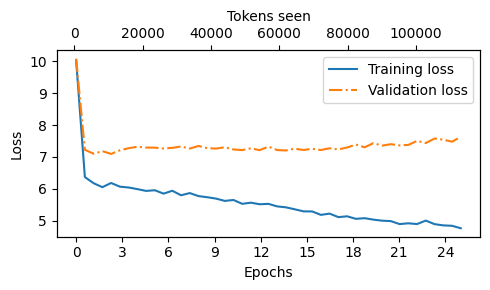

In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = mx.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [50]:
def topk(x, top_k, axis=-1):
    """
    Returns the top-k values and indices along a specified axis.
    
    Args:
        x (mlx.core.array): The input array.
        top_k (int): The number of top elements to retrieve.
        axis (int): The axis along which to compute the top-k elements.
        
    Returns:
        tuple: A tuple containing (values, indices).
    """
    # Get the indices for a descending sort by sorting the negated array
    sorted_indices = mx.argsort(-x, axis=axis)
    
    # Slice the sorted indices to get the top-k indices
    top_k_indices = mx.take(sorted_indices, mx.arange(top_k), axis=axis)
    
    # Create the batch indices for advanced indexing
    batch_indices = mx.arange(x.shape[0])[:, None]
    
    # Use the mx.broadcast_to function to create a compatible shape
    broadcasted_batch_indices = mx.broadcast_to(batch_indices, top_k_indices.shape)
    
    # Use advanced indexing to get the top-k values
    values = x[broadcasted_batch_indices, top_k_indices]
    
    return values, top_k_indices

In [51]:
ex = mx.array([[10, 2, 5, 8, 3],
              [7, 15, 1, 9, 6]])

k = 3
values, indices = topk(ex, k, axis=-1)

print("Original array:")
print(ex)
print("\nTop-k values:")
print(values)
print("\nTop-k indices:")
print(indices)

Original array:
array([[10, 2, 5, 8, 3],
       [7, 15, 1, 9, 6]], dtype=int32)

Top-k values:
array([[10, 8, 5],
       [15, 9, 7]], dtype=int32)

Top-k indices:
array([[0, 3, 2],
       [1, 3, 0]], dtype=uint32)


In [52]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    # MLX does not have a no_grad context manager; computation is lazy by default
    
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        logits = model(idx_cond)
        logits = logits[:, -1, :]
        
        # MLX `mx.topk` returns values and indices, same as PyTorch
        if top_k is not None:
            # Keep only top_k values
            top_logits, top_ids = topk(logits, top_k)
            min_val = top_logits[:, -1]
            
            # Use mx.where for conditional masking
            logits = mx.where(logits < min_val, mx.array(float("-inf"), logits.dtype), logits)
            
        # Apply temperature scaling and sampling
        if temperature > 0.0:
            logits = logits / temperature
            # MLX `mx.random.categorical` is the equivalent of `torch.multinomial`
            idx_next = mx.random.categorical(logits, axis=-1, num_samples=1)
            
        # Otherwise, use greedy decoding
        else:
            # `keepdims` in PyTorch is `keepdim` in MLX
            idx_next = mx.argmax(logits, axis=-1, keepdims=True)
        
        # Check for end-of-sequence token
        if eos_id is not None and mx.any(mx.equal(idx_next, eos_id)):
            break
            
        # Append the new token
        idx = mx.concatenate((idx, idx_next), axis=1)
        # Force computation and sync to handle eager logic in a lazy framework
        mx.eval(idx)

    return idx

In [53]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you I at had down." . to my
He---. .


In [54]:
model.save_weights("gpt-model-weights.safetensors")

In [55]:
new_model = GPTModel(GPT_CONFIG_124M)
new_model.load_weights("gpt-model-weights.safetensors")
new_model.eval()

token_ids = generate(
    model=new_model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you the had he you my
There
and his surprise him to't to


In [56]:
# 1. Get the nested parameters
params = model.parameters()

# 2. Flatten the nested dictionary
# This returns a list of tuples like [('fc1.weight', array), ('fc1.bias', array), ...]
flat_params = utils.tree_flatten(params)

# 3. Convert the list of tuples back into a flat dictionary
# This is a common Python pattern for creating a dictionary from a list of key-value pairs
flat_params_dict = {k: v for k, v in flat_params}

# Now, save the flat dictionary
mx.savez("gpt-model-weights.npz", **flat_params_dict)


In [57]:
_ = utils.tree_map_with_path(lambda path, p: print(f"Key: {path}, Shape: {p.shape}") or p.shape, model.parameters())

Key: tok_emb.weight, Shape: (50257, 768)
Key: pos_emb.weight, Shape: (256, 768)
Key: trf_blocks.layers.0.att.W_query.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_key.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_value.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.out_proj.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.out_proj.bias, Shape: (768,)
Key: trf_blocks.layers.0.ff.layers.layers.0.weight, Shape: (3072, 768)
Key: trf_blocks.layers.0.ff.layers.layers.0.bias, Shape: (3072,)
Key: trf_blocks.layers.0.ff.layers.layers.2.weight, Shape: (768, 3072)
Key: trf_blocks.layers.0.ff.layers.layers.2.bias, Shape: (768,)
Key: trf_blocks.layers.0.norm1.scale, Shape: (768,)
Key: trf_blocks.layers.0.norm1.shift, Shape: (768,)
Key: trf_blocks.layers.0.norm2.scale, Shape: (768,)
Key: trf_blocks.layers.0.norm2.shift, Shape: (768,)
Key: trf_blocks.layers.1.att.W_query.weight, Shape: (768, 768)
Key: trf_blocks.layers.1.att.W_key.weight, Shape: (768, 768)
Key: trf

In [58]:
print("\n".join([f"Key: {key}, Shape: {value.shape}" for key, value in flat_params]))

Key: tok_emb.weight, Shape: (50257, 768)
Key: pos_emb.weight, Shape: (256, 768)
Key: trf_blocks.layers.0.att.W_query.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_key.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_value.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.out_proj.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.out_proj.bias, Shape: (768,)
Key: trf_blocks.layers.0.ff.layers.layers.0.weight, Shape: (3072, 768)
Key: trf_blocks.layers.0.ff.layers.layers.0.bias, Shape: (3072,)
Key: trf_blocks.layers.0.ff.layers.layers.2.weight, Shape: (768, 3072)
Key: trf_blocks.layers.0.ff.layers.layers.2.bias, Shape: (768,)
Key: trf_blocks.layers.0.norm1.scale, Shape: (768,)
Key: trf_blocks.layers.0.norm1.shift, Shape: (768,)
Key: trf_blocks.layers.0.norm2.scale, Shape: (768,)
Key: trf_blocks.layers.0.norm2.shift, Shape: (768,)
Key: trf_blocks.layers.1.att.W_query.weight, Shape: (768, 768)
Key: trf_blocks.layers.1.att.W_key.weight, Shape: (768, 768)
Key: trf

In [59]:
new_model = GPTModel(GPT_CONFIG_124M)

# Assume 'gpt-model-weights.npz.npz' is the file saved using the flattened method
# Load the flattened parameters
loaded_flat_params = mx.load("gpt-model-weights.npz")

# Unflatten the dictionary to restore the nested structure
unflattened_params = utils.tree_unflatten(loaded_flat_params)

# Update the new model with the loaded and unflattened parameters
new_model.update(unflattened_params)

new_model.eval()

token_ids = generate(
    model=new_model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you I tell it down to to. to a of-- I had to the


In [60]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.19.0
tqdm version: 4.67.1


In [61]:
# Relative import from the gpt_download.py contained in this folder

from mlxgpt.gpt_download import download_and_load_gpt2
# Alternatively:
# from llms_from_scratch.ch05 import download_and_load_gpt2

In [62]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77.0/77.0 [00:00<00:00, 92.4kiB/s]
encoder.json: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.04M/1.04M [00:00<00:00, 2.50MiB/s]
hparams.json: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90.0/90.0 [00:00<00:00, 82.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 498M/498M [00:13<00:00, 35.8MiB/s]
model.ckpt.index: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.21k/5.21k [00:00<00:00, 2.13MiB/s]
model.ckpt.meta: 100%|█████████████████████████████████████████████████████

In [63]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [64]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [65]:
_ = utils.tree_map_with_path(lambda path, p: print(f"Key: {path}, Shape: {p.shape}") or p.shape, gpt.parameters())

Key: tok_emb.weight, Shape: (50257, 768)
Key: pos_emb.weight, Shape: (1024, 768)
Key: trf_blocks.layers.0.att.W_query.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_query.bias, Shape: (768,)
Key: trf_blocks.layers.0.att.W_key.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_key.bias, Shape: (768,)
Key: trf_blocks.layers.0.att.W_value.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.W_value.bias, Shape: (768,)
Key: trf_blocks.layers.0.att.out_proj.weight, Shape: (768, 768)
Key: trf_blocks.layers.0.att.out_proj.bias, Shape: (768,)
Key: trf_blocks.layers.0.ff.layers.layers.0.weight, Shape: (3072, 768)
Key: trf_blocks.layers.0.ff.layers.layers.0.bias, Shape: (3072,)
Key: trf_blocks.layers.0.ff.layers.layers.2.weight, Shape: (768, 3072)
Key: trf_blocks.layers.0.ff.layers.layers.2.bias, Shape: (768,)
Key: trf_blocks.layers.0.norm1.scale, Shape: (768,)
Key: trf_blocks.layers.0.norm1.shift, Shape: (768,)
Key: trf_blocks.layers.0.norm2.scale, Shape: (768,)
Key: trf_block

In [66]:
_ = utils.tree_map_with_path(lambda path, p: print(f"Key: {path}, Shape: {p.shape}") or p.shape, params)

Key: blocks.0.attn.c_attn.b, Shape: (2304,)
Key: blocks.0.attn.c_attn.w, Shape: (768, 2304)
Key: blocks.0.attn.c_proj.b, Shape: (768,)
Key: blocks.0.attn.c_proj.w, Shape: (768, 768)
Key: blocks.0.ln_1.b, Shape: (768,)
Key: blocks.0.ln_1.g, Shape: (768,)
Key: blocks.0.ln_2.b, Shape: (768,)
Key: blocks.0.ln_2.g, Shape: (768,)
Key: blocks.0.mlp.c_fc.b, Shape: (3072,)
Key: blocks.0.mlp.c_fc.w, Shape: (768, 3072)
Key: blocks.0.mlp.c_proj.b, Shape: (768,)
Key: blocks.0.mlp.c_proj.w, Shape: (3072, 768)
Key: blocks.1.attn.c_attn.b, Shape: (2304,)
Key: blocks.1.attn.c_attn.w, Shape: (768, 2304)
Key: blocks.1.attn.c_proj.b, Shape: (768,)
Key: blocks.1.attn.c_proj.w, Shape: (768, 768)
Key: blocks.1.ln_1.b, Shape: (768,)
Key: blocks.1.ln_1.g, Shape: (768,)
Key: blocks.1.ln_2.b, Shape: (768,)
Key: blocks.1.ln_2.g, Shape: (768,)
Key: blocks.1.mlp.c_fc.b, Shape: (3072,)
Key: blocks.1.mlp.c_fc.w, Shape: (768, 3072)
Key: blocks.1.mlp.c_proj.b, Shape: (768,)
Key: blocks.1.mlp.c_proj.w, Shape: (3072, 768

In [67]:
print(type(params["g"]))
print(type(gpt.final_norm.scale))
print(gpt.trf_blocks.layers[0].att.W_query.weight.shape)

<class 'numpy.ndarray'>
<class 'mlx.core.array'>
(768, 768)


In [68]:
import numpy as np

def assign(left: mx.array, right: np.ndarray) -> mx.array:
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return mx.array(right)

In [69]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks.layers[b].att.W_query.weight = assign(
            gpt.trf_blocks.layers[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks.layers[b].att.W_key.weight = assign(
            gpt.trf_blocks.layers[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks.layers[b].att.W_value.weight = assign(
            gpt.trf_blocks.layers[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks.layers[b].att.W_query.bias = assign(
            gpt.trf_blocks.layers[b].att.W_query.bias, q_b)
        gpt.trf_blocks.layers[b].att.W_key.bias = assign(
            gpt.trf_blocks.layers[b].att.W_key.bias, k_b)
        gpt.trf_blocks.layers[b].att.W_value.bias = assign(
            gpt.trf_blocks.layers[b].att.W_value.bias, v_b)

        gpt.trf_blocks.layers[b].att.out_proj.weight = assign(
            gpt.trf_blocks.layers[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks.layers[b].att.out_proj.bias = assign(
            gpt.trf_blocks.layers[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks.layers[b].ff.layers.layers[0].weight = assign(
            gpt.trf_blocks.layers[b].ff.layers.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks.layers[b].ff.layers.layers[0].bias = assign(
            gpt.trf_blocks.layers[b].ff.layers.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks.layers[b].ff.layers.layers[2].weight = assign(
            gpt.trf_blocks.layers[b].ff.layers.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks.layers[b].ff.layers.layers[2].bias = assign(
            gpt.trf_blocks.layers[b].ff.layers.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks.layers[b].norm1.scale = assign(
            gpt.trf_blocks.layers[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks.layers[b].norm1.shift = assign(
            gpt.trf_blocks.layers[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks.layers[b].norm2.scale = assign(
            gpt.trf_blocks.layers[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks.layers[b].norm2.shift = assign(
            gpt.trf_blocks.layers[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)

In [70]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you to believe." He started talking about himself and other people with disabilities with "just love." There were so many more details."
